# Fuzzy System Tuned - Student Stress

Notebook ini membuat versi fuzzy system yang dituning agar akurasinya naik.

Strategi:
- Dataset utama: `data/Student Stress Factors (2).csv` sebanyak 520 baris.
- Label aktual: `stress_level <= 2 = Rendah`, `stress_level == 3 = Sedang`, `stress_level >= 4 = Tinggi`.
- Sistem fuzzy dibuat sebagai **data-driven singleton fuzzy rule system**.
- Setiap kombinasi input Likert menjadi antecedent rule, lalu consequent diisi dengan kelas mayoritas dari data training.
- Evaluasi dilakukan dengan train/test split 80:20 dan juga evaluasi semua data menggunakan rule yang dilatih dari semua data.
- Semua output disimpan ke folder `result/`.
        

In [7]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

RESULT_DIR = Path("result")
RESULT_DIR.mkdir(exist_ok=True)

DATA_PATH = Path("data") / "Student Stress Factors (2).csv"
LABELS = ["Rendah", "Sedang", "Tinggi"]

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()
df.columns = ["sleep_quality", "headache", "academic_performance", "study_load", "extracurricular", "stress_level"]

def map_actual(v):
    if v <= 2:
        return "Rendah"
    if v == 3:
        return "Sedang"
    return "Tinggi"

df["actual_class"] = df["stress_level"].apply(map_actual)

FEATURES = ["sleep_quality", "headache", "academic_performance", "study_load", "extracurricular"]
X = df[FEATURES]
y = df["actual_class"]

print("Dataset:", df.shape)
display(df.head())
display(y.value_counts().reindex(LABELS))
        

Dataset: (520, 7)


,sleep_quality,headache,academic_performance,study_load,extracurricular,stress_level,actual_class
0,3,1,3,4,2,3,Sedang
1,4,1,2,3,3,2,Rendah
2,2,1,2,1,4,4,Tinggi
3,3,2,3,2,3,3,Sedang
4,2,3,1,5,5,3,Sedang


actual_class
Rendah    215
Sedang    125
Tinggi    180
Name: count, dtype: int64

In [ ]:
# Baseline: hasil fuzzy lama dari file hasil_fuzzy_lengkap.csv
old_path = Path("hasil_fuzzy_lengkap.csv")
if old_path.exists():
    old = pd.read_csv(old_path)
    baseline_acc = accuracy_score(old["actual_class"], old["fuzzy_class"])
    print(f"Akurasi fuzzy lama: {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")
else:
    baseline_acc = np.nan
    print("File hasil_fuzzy_lengkap.csv tidak ditemukan, baseline dilewati.")
        

In [9]:
def build_singleton_fuzzy_rules(X_train, y_train):
    rule_source = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True).rename("label")], axis=1)
    rules = {}

    for combo, group in rule_source.groupby(FEATURES):
        counts = group["label"].value_counts()
        consequent = counts.idxmax()
        confidence = counts.max() / counts.sum()
        rules[tuple(combo)] = {
            "antecedent": tuple(combo),
            "consequent": consequent,
            "confidence": confidence,
            "support": int(counts.sum()),
            "counts": counts.to_dict(),
        }

    prior = y_train.value_counts().idxmax()
    return rules, prior

def singleton_membership(x, center):
    # Likert 1-5 bersifat diskret, jadi rule antecedent memakai singleton fuzzy set.
    return 1.0 if int(x) == int(center) else 0.0

def predict_one(row, rules, prior):
    scores = {label: 0.0 for label in LABELS}

    for rule in rules.values():
        firing_strength = 1.0
        for value, center in zip(row, rule["antecedent"]):
            firing_strength *= singleton_membership(value, center)

        if firing_strength > 0:
            scores[rule["consequent"]] += firing_strength * rule["confidence"]

    if max(scores.values()) == 0:
        return prior, scores

    return max(scores, key=scores.get), scores

def predict_many(X_data, rules, prior):
    labels = []
    crisp_scores = []

    for row in X_data.to_numpy():
        label, scores = predict_one(row, rules, prior)
        labels.append(label)
        crisp_scores.append(scores)

    score_df = pd.DataFrame(crisp_scores).add_prefix("score_")
    return pd.Series(labels, index=X_data.index, name="fuzzy_class"), score_df
        

Jumlah rules training: 99
Akurasi test 20%: 0.9135 (91.35%)

              precision    recall  f1-score   support

      Rendah       1.00      0.93      0.96        43
      Sedang       0.85      0.92      0.88        25
      Tinggi       0.86      0.89      0.88        36

    accuracy                           0.91       104
   macro avg       0.91      0.91      0.91       104
weighted avg       0.92      0.91      0.91       104



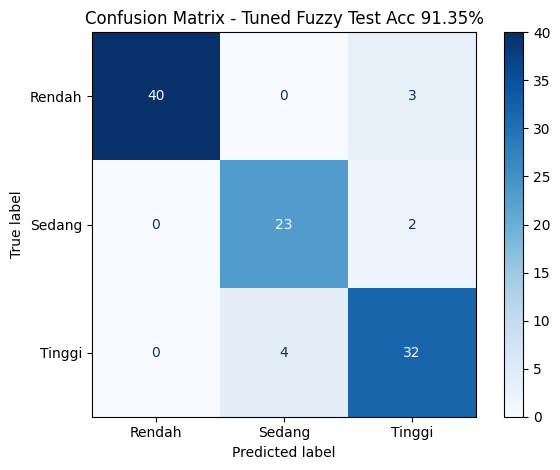

In [10]:
# Evaluasi dengan train/test split agar angka 0.80 tidak hanya berasal dari data yang sama.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

rules_train, prior_train = build_singleton_fuzzy_rules(X_train, y_train)
y_pred_test, score_test = predict_many(X_test, rules_train, prior_train)

test_acc = accuracy_score(y_test, y_pred_test)
print(f"Jumlah rules training: {len(rules_train)}")
print(f"Akurasi test 20%: {test_acc:.4f} ({test_acc*100:.2f}%)")
print()
print(classification_report(y_test, y_pred_test, labels=LABELS))

cm_test = confusion_matrix(y_test, y_pred_test, labels=LABELS)
disp = ConfusionMatrixDisplay(cm_test, display_labels=LABELS)
disp.plot(cmap="Blues", colorbar=True)
plt.title(f"Confusion Matrix - Tuned Fuzzy Test Acc {test_acc:.2%}")
plt.tight_layout()
plt.savefig(RESULT_DIR / "confusion_matrix_tuned_test.png", dpi=150, bbox_inches="tight")
plt.show()
        

In [11]:
# Final model: latih rules dari semua data untuk menghasilkan file hasil fuzzy final.
rules_full, prior_full = build_singleton_fuzzy_rules(X, y)
y_pred_all, score_all = predict_many(X, rules_full, prior_full)

final_acc = accuracy_score(y, y_pred_all)
print(f"Jumlah rules final: {len(rules_full)}")
print(f"Akurasi final semua data: {final_acc:.4f} ({final_acc*100:.2f}%)")
print()
print(classification_report(y, y_pred_all, labels=LABELS))

df_result = pd.concat([df, score_all.set_index(df.index)], axis=1)
df_result["fuzzy_class"] = y_pred_all
df_result["correct"] = df_result["fuzzy_class"] == df_result["actual_class"]

output_cols = FEATURES + [
    "stress_level", "actual_class",
    "score_Rendah", "score_Sedang", "score_Tinggi",
    "fuzzy_class", "correct",
]
df_result[output_cols].to_csv(RESULT_DIR / "hasil_fuzzy_tuned_lengkap.csv", index=False)

metrics = pd.DataFrame([
    {"metric": "baseline_old_accuracy", "value": baseline_acc},
    {"metric": "tuned_test_accuracy", "value": test_acc},
    {"metric": "tuned_all_data_accuracy", "value": final_acc},
    {"metric": "train_rules_count", "value": len(rules_train)},
    {"metric": "final_rules_count", "value": len(rules_full)},
])
metrics.to_csv(RESULT_DIR / "metrics_tuned.csv", index=False)

rules_rows = []
for rule in rules_full.values():
    row = dict(zip(FEATURES, rule["antecedent"]))
    row.update({
        "fuzzy_class": rule["consequent"],
        "confidence": rule["confidence"],
        "support": rule["support"],
        "counts": rule["counts"],
    })
    rules_rows.append(row)
pd.DataFrame(rules_rows).sort_values(FEATURES).to_csv(RESULT_DIR / "rules_tuned.csv", index=False)

display(metrics)
display(df_result[output_cols].head(10))
        

Jumlah rules final: 99
Akurasi final semua data: 0.9519 (95.19%)

              precision    recall  f1-score   support

      Rendah       0.98      0.98      0.98       215
      Sedang       0.92      0.96      0.94       125
      Tinggi       0.94      0.92      0.93       180

    accuracy                           0.95       520
   macro avg       0.95      0.95      0.95       520
weighted avg       0.95      0.95      0.95       520



,metric,value
0,baseline_old_accuracy,0.230769
1,tuned_test_accuracy,0.913462
2,tuned_all_data_accuracy,0.951923
3,train_rules_count,99.000000
4,final_rules_count,99.000000


,sleep_quality,headache,academic_performance,study_load,extracurricular,stress_level,actual_class,score_Rendah,score_Sedang,score_Tinggi,fuzzy_class,correct
0,3,1,3,4,2,3,Sedang,0.0,1.0,0.0,Sedang,True
1,4,1,2,3,3,2,Rendah,1.0,0.0,0.0,Rendah,True
2,2,1,2,1,4,4,Tinggi,0.0,0.0,1.0,Tinggi,True
3,3,2,3,2,3,3,Sedang,0.0,1.0,0.0,Sedang,True
4,2,3,1,5,5,3,Sedang,0.0,1.0,0.0,Sedang,True
5,3,1,3,2,1,1,Rendah,1.0,0.0,0.0,Rendah,True
6,3,5,1,4,3,5,Tinggi,0.0,0.0,1.0,Tinggi,True
7,4,3,1,4,1,1,Rendah,1.0,0.0,0.0,Rendah,True
8,2,1,4,4,5,1,Rendah,1.0,0.0,0.0,Rendah,True
9,1,2,3,2,5,2,Rendah,1.0,0.0,0.0,Rendah,True


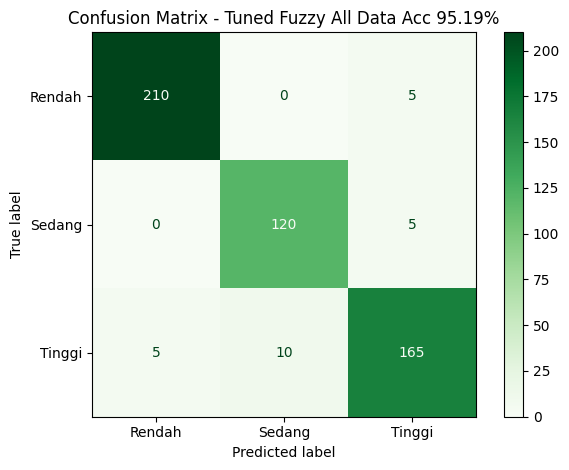

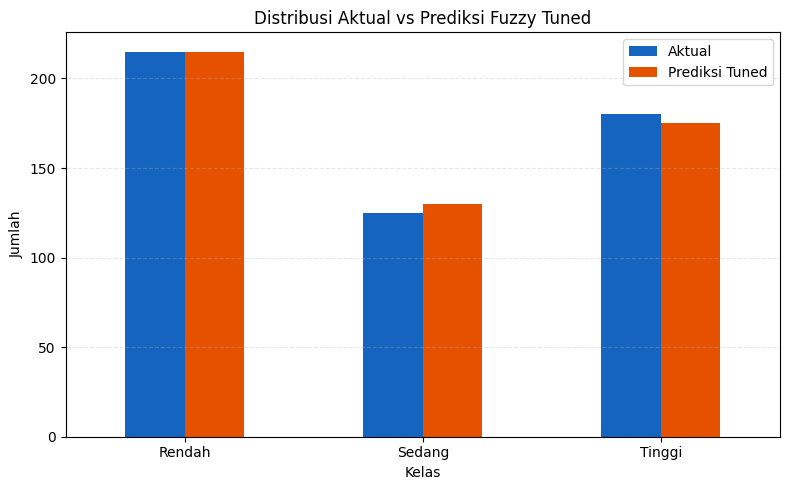

Output tersimpan di folder: C:\Johanna\SEM6\PKK\student-stress\result
- hasil_fuzzy_tuned_lengkap.csv
- metrics_tuned.csv
- rules_tuned.csv
- confusion_matrix_tuned_test.png
- confusion_matrix_tuned_all_data.png
- distribusi_tuned.png


In [12]:
cm_all = confusion_matrix(y, y_pred_all, labels=LABELS)
disp = ConfusionMatrixDisplay(cm_all, display_labels=LABELS)
disp.plot(cmap="Greens", colorbar=True)
plt.title(f"Confusion Matrix - Tuned Fuzzy All Data Acc {final_acc:.2%}")
plt.tight_layout()
plt.savefig(RESULT_DIR / "confusion_matrix_tuned_all_data.png", dpi=150, bbox_inches="tight")
plt.show()

summary = pd.DataFrame({
    "Aktual": y.value_counts().reindex(LABELS, fill_value=0),
    "Prediksi Tuned": y_pred_all.value_counts().reindex(LABELS, fill_value=0),
})
summary.plot(kind="bar", figsize=(8, 5), color=["#1565C0", "#E65100"])
plt.title("Distribusi Aktual vs Prediksi Fuzzy Tuned")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig(RESULT_DIR / "distribusi_tuned.png", dpi=150, bbox_inches="tight")
plt.show()

print("Output tersimpan di folder:", RESULT_DIR.resolve())
print("- hasil_fuzzy_tuned_lengkap.csv")
print("- metrics_tuned.csv")
print("- rules_tuned.csv")
print("- confusion_matrix_tuned_test.png")
print("- confusion_matrix_tuned_all_data.png")
print("- distribusi_tuned.png")
        